## Problem Statement

- Predict whether a telecom customer will churn or not
- using customer demographics and service information.


## Data Preprocessing

- Data Preprocessing
- Removed unnecessary columns
- Handled missing values
- Converted categorical features into numerical format
- Applied One-Hot Encoding and Ordinal Encoding
- Scaled numerical features where required
- Split the dataset into training and testing sets



## Customer Churn Prediction

## Model Building

- Created preprocessing and modeling pipelines
- Trained multiple machine learning models
- Compared model performance using cross-validation
- Tuned hyperparameters for the best-performing model

## Model Evaluation

- Evaluated models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
- Analyzed confusion matrix and classification report
- Selected the best model based on overall performance

## Outcome

- The final model helps identify customers who are likely to churn,
-  enabling businesses to take proactive retention actions and improve customer loyalty.

## Import Required Libraries

In [27]:

# Data Manipulation
import pandas as pd

# Model Saving & Loading
import joblib

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split & Model Evaluation
from sklearn.model_selection import train_test_split, cross_validate

# Pipeline & Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Feature Engineering & Data Preprocessing
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

# Missing Value Handling
from sklearn.impute import SimpleImputer

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore Warning Messages
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn"
)

## Load Dataset

In [28]:

df=pd.read_csv('Telco-Customer-Churn.csv')

# Create a copy of the original dataset
# to preserve raw data during preprocessing

data=df.copy()

In [29]:
# Display first five records

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Data Exploration

In [30]:
# Check dataset shape
data.shape

(7043, 21)

In [31]:
# Check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
# Check duplicates
data.duplicated().sum()

np.int64(0)

In [33]:
# Check missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [34]:
# Remove CustomerID

data=data.drop(columns='customerID')

In [35]:
# Convert TotalCharges to Numeric

data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'],
    errors='coerce'
)

In [36]:
# Check missing values

data.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
# Handle Missing Values

data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].median())

In [38]:
# Handle Special Categories

# Replace service-specific categories with 'No'
# to reduce unnecessary category levels

data['MultipleLines']=data['MultipleLines'].replace('No phone service','No')

for i in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    data[i]=data[i].replace('No internet service','No')

## Exploratory Data Analysis

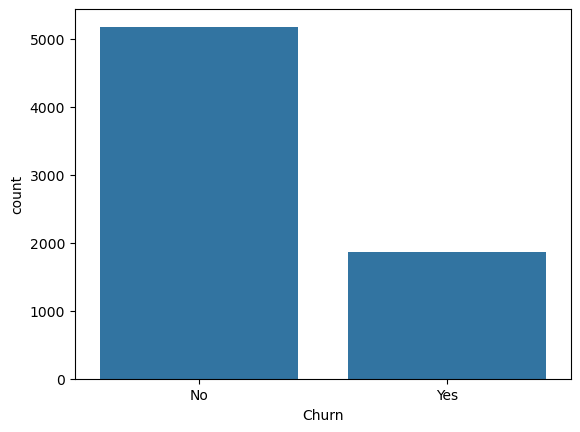

In [39]:
#Target Distribution

sns.countplot(x='Churn',data=data)
plt.show()

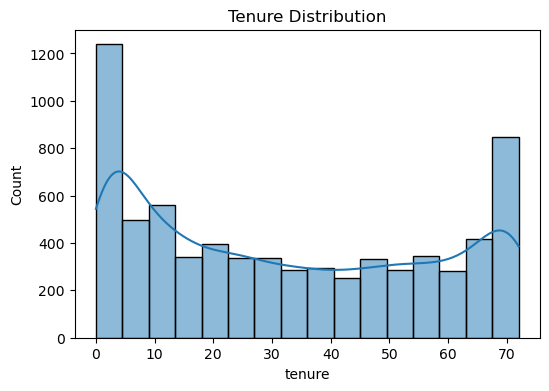

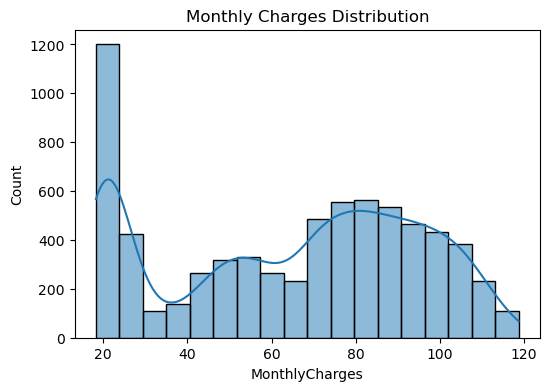

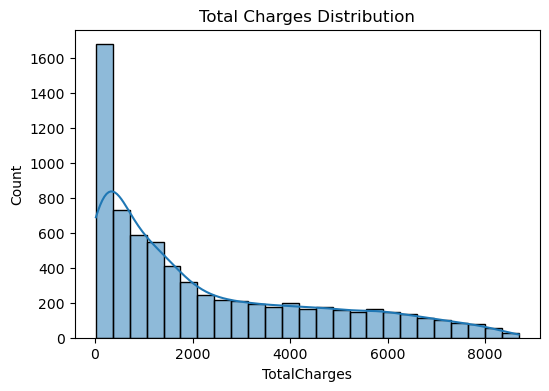

In [40]:
# Numerical Distribution

plt.figure(figsize=(6,4))
sns.histplot(data['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data['TotalCharges'], kde=True)
plt.title("Total Charges Distribution")
plt.show()

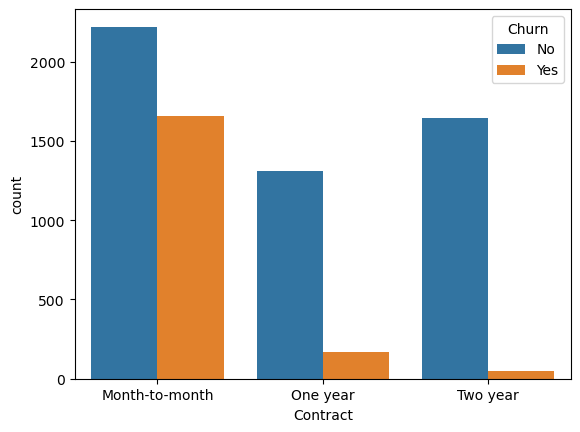

In [41]:
# Churn vs Contract

sns.countplot(
    x='Contract',
    data=data,
    hue='Churn'
)

plt.show()

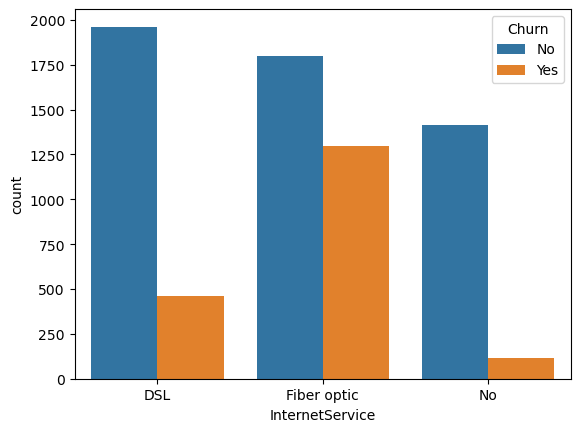

In [42]:
# Churn vs InternetService

sns.countplot(
    x='InternetService',
    data=data,
    hue='Churn'
)

plt.show()

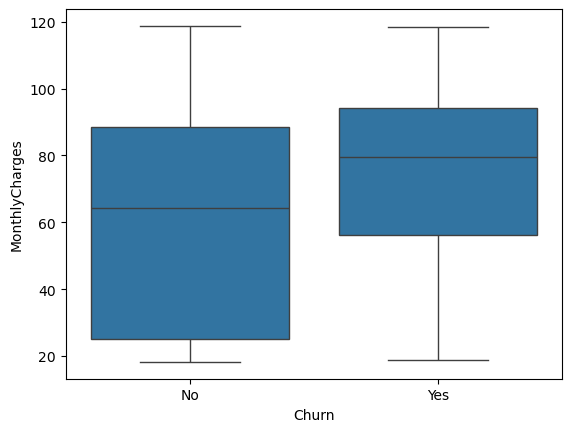

In [43]:
# MonthlyCharges vs Churn

sns.boxplot(
    x='Churn',
    data=data,
    y='MonthlyCharges'
)

plt.show()

In [44]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Outlier Analysis

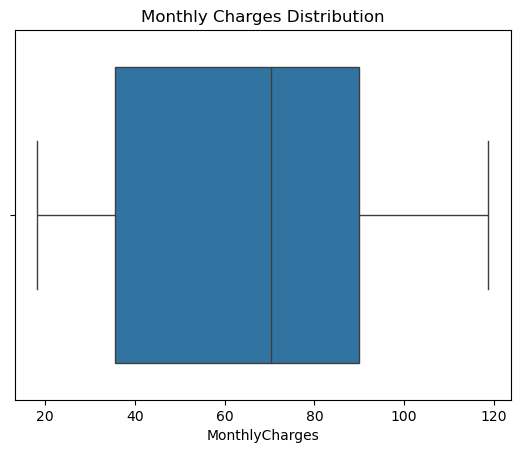

In [45]:
#Outlier Analysis for monthly charges

sns.boxplot(x=df['MonthlyCharges'])
plt.title("Monthly Charges Distribution")
plt.show()

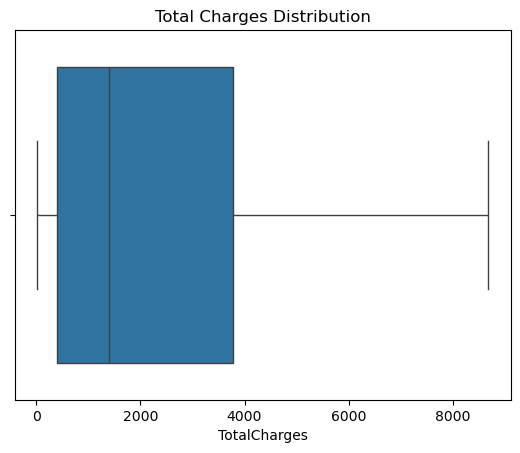

In [46]:
# Outlier Analysis for total charges

sns.boxplot(x=data['TotalCharges'])
plt.title("Total Charges Distribution")
plt.show()

## Feature Selection

In [47]:
# Separate features and target variable

X=data.drop(columns='Churn')
y=data['Churn'].map({'No':0,'Yes':1})

In [ ]:
# Identify categorical and numerical features

cat_col=X.select_dtypes(include='object')
num_col=X.select_dtypes(exclude='object').columns.tolist()

# Split categorical features into binary and multi-category groups

bin_cat_col=cat_col.drop(columns=['InternetService','Contract','PaymentMethod']).columns.tolist()
ohe_cat_col=['InternetService','Contract','PaymentMethod']

## Train Test Split

In [48]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Data Preprocessing Pipeline

In [49]:

# Define machine learning models for comparison

models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced',max_iter=1000),
    'RandomForest': RandomForestClassifier(class_weight='balanced',random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42,verbosity=-1)
}

# Create preprocessing pipeline for numerical and categorical features

preprocess = ColumnTransformer(
    [
        # Numerical feature preprocessing
        
        (
            'num',
            Pipeline(
                [
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]
            ),
            num_col
        ),

        # Binary categorical feature preprocessing
        
        (
            'bin_cat',
            Pipeline(
                [
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OrdinalEncoder())
                ]
            ),
            bin_cat_col
        ),

        # One-hot encoding for multi-category features
        
        (
            'ohe_cat',
            Pipeline(
                [
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
                ]
            ),
            ohe_cat_col
        )
    ],
    remainder='passthrough'
)


# Baseline Model Comparison

In [50]:
# Compare multiple models using cross-validation

result=[]
for name,model in models.items():
    
   # Create end-to-end pipeline
    
    pipe=Pipeline(
        [
            ('preprocess',preprocess),
            ('model',model)
        ]
    )

    # Evaluate model using F1 Score and ROC-AUC
    
    score=cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=['f1','roc_auc']
    )

    # Store average cross-validation scores
    
    result.append({'model':name,
                   'f1':score['test_f1'].mean(),
                   'roc_auc':score['test_roc_auc'].mean()
                  }
                 )

# Create model comparison table

cv=pd.DataFrame(result)

# Sort models by ROC-AUC score

cv.sort_values(by='roc_auc',ascending=False)

,model,f1,roc_auc
0,LogisticRegression,0.633421,0.845241
5,CatBoost,0.572121,0.842445
3,HistGradientBoosting,0.569699,0.834119
7,LightGBM,0.571440,0.831916
1,RandomForest,0.538741,0.824545
4,XGBoost,0.556782,0.821843
2,ExtraTrees,0.530523,0.798432
6,DecisionTree,0.495701,0.656441


## Hyperparameter Tuning

- This section optimizes the best-performing models
- using GridSearchCV to improve predictive
- performance and identify the optimal hyperparameter combination.

In [51]:
# Hyperparameter Tuning for Logistic Regression using GridSearchCV

# Create logistic pipeline with preprocessing

pipe=Pipeline(
    [
        ('preprocess',preprocess),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)

# Define hyperparameter search space

param_dist = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

# Perform GridSearchCV hyperparameter search

log_r=GridSearchCV(
    pipe,
    param_dist,
    cv=5,
    scoring='f1',
)

# Train model and find best parameters

log_r.fit(X_train,y_train)

# Display best results

print("Best Parameters:", log_r.best_params_)
print("Best Cross Validation Score:", log_r.best_score_)

Best Parameters: {'model__C': 1, 'model__solver': 'lbfgs'}
Best Cross Validation Score: 0.6334207246490632


In [52]:
# Hyperparameter Tuning for LightGBM using RandomizedSearchCV

# Create LightGBM pipeline with preprocessing

pipe=Pipeline(
    [
        ('preprocess',preprocess),
        ('model',LGBMClassifier(random_state=42,verbosity=-1))
    ]
)

# Define hyperparameter search space

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, -1],
    'model__num_leaves': [15, 31, 63]
}

# Perform randomized hyperparameter search

lgbm=RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1
)

# Train model and find best parameters

lgbm.fit(X_train,y_train)

# Display best results

print("Best Parameters:", lgbm.best_params_)
print("Best Cross Validation Score:", lgbm.best_score_)

Best Parameters: {'model__num_leaves': 15, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.05}
Best Cross Validation Score: 0.5809108250378338


In [53]:
# Hyperparameter Tuning for CatBoost using RandomizedSearchCV

# Create CatBoost pipeline with preprocessing

pipe=Pipeline(
    [
        ('preprocess',preprocess),
        ('model',CatBoostClassifier(verbose=0, random_state=42))
    ]
)

## Define hyperparameter search space

param_dist = {
    'model__iterations': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [4, 6, 8]
}

# Perform randomized hyperparameter search

cat_b=RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=27,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Train model and find best parameters

cat_b.fit(X_train,y_train)

# Display best results

print("Best Parameters:", cat_b.best_params_)
print("Best Cross Validation Score:", cat_b.best_score_)

Best Parameters: {'model__learning_rate': 0.05, 'model__iterations': 200, 'model__depth': 4}
Best Cross Validation Score: 0.5909335111527771


# Compare Tuned Models

In [54]:
# Compare Tuned Models

results = pd.DataFrame({
    'Model': ['LogisticRegression','LGBMClassifier','CatBoostClassifier'],
    'Best_CV_Score': [
        log_r.best_score_,
        lgbm.best_score_,
        cat_b.best_score_
    ]
})

results.sort_values('Best_CV_Score', ascending=False)

,Model,Best_CV_Score
0,LogisticRegression,0.633421
2,CatBoostClassifier,0.590934
1,LGBMClassifier,0.580911


# Final Model Selection

In [55]:
#best model

best_model=log_r.best_estimator_

best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder()...
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('ohe_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    max_iter=1000))])

## Model Evaluation

In [56]:
y_pred = best_model.predict(X_test)


In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7388218594748048
Precision: 0.5051724137931034
Recall   : 0.7834224598930482
F1 Score : 0.6142557651991615


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [59]:

print(confusion_matrix(y_test, y_pred))

[[748 287]
 [ 81 293]]


In [60]:

print(roc_auc_score(y_test, y_pred))

0.753063886951355


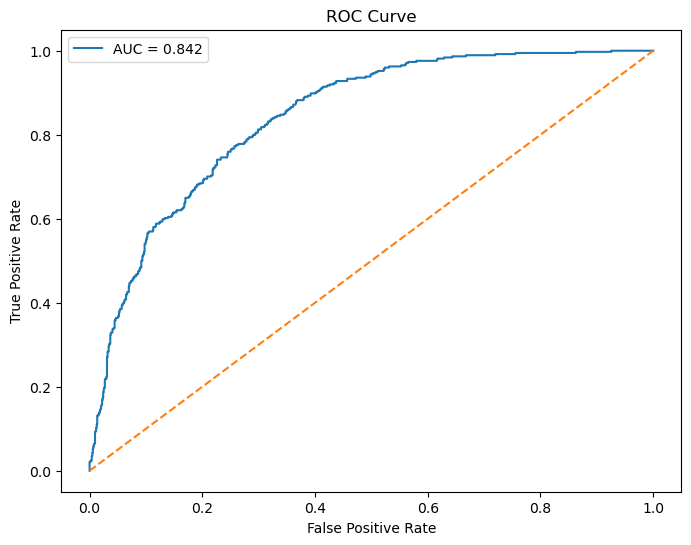

In [61]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Feature Importance Analysis

In [62]:
# feature names after preprocessing
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

# coefficients
coef = best_model.named_steps['model'].coef_[0]

# dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
})

# absolute importance
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()

# sort
importance_df = importance_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

importance_df.head(20)

,Feature,Coefficient,Abs_Coefficient
19,ohe_cat__Contract_Two year,-1.417760,1.417760
1,num__tenure,-1.145727,1.145727
17,ohe_cat__InternetService_No,-1.121341,1.121341
16,ohe_cat__InternetService_Fiber optic,1.084021,1.084021
18,ohe_cat__Contract_One year,-0.721257,0.721257
3,num__TotalCharges,0.473730,0.473730
21,ohe_cat__PaymentMethod_Electronic check,0.399868,0.399868
2,num__MonthlyCharges,-0.373182,0.373182
14,bin_cat__StreamingMovies,0.366985,0.366985
9,bin_cat__OnlineSecurity,-0.360641,0.360641


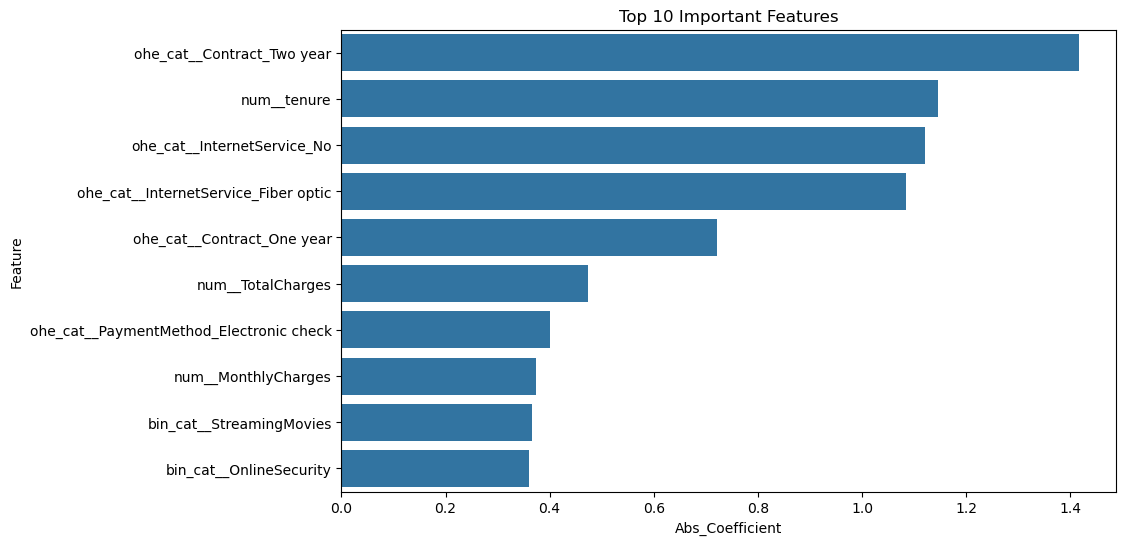

In [63]:
top10 = importance_df.sort_values(
    'Abs_Coefficient',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='Abs_Coefficient',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

## Save Trained Model

In [64]:
# savev model

joblib.dump(best_model,'Telco_Customer_Churn.joblib')

print('Save Sucessful ✅ ')

['Telco_Customer_Churn.joblib']